Import Libraries

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

from sklearn.ensemble import RandomForestRegressor

from itertools import chain, combinations

Set Dataset Path

In [142]:
DATA_PATH = "datasets/patuakhali_soil_element (Ec,PH,NPKS).xlsm - English Data (1).csv"

Load Dataset

In [143]:
df = pd.read_csv(DATA_PATH)
df.head()

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Available Phosphorus (B)* (µg/g soil),Available Phosphorus (O)** (µg/g soil),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil)
0,4,Ramgati,Medium high land,Loam,8.0,1.63,0.95,0.06,18.19,NaN,0.07,20.30,0.09,0.35,7.06,1.83,0.70,1.08
1,5,Rangamati,Medium high land,Loam,6.5,1.25,1.31,0.08,0.00,2.64,0.07,12.01,0.14,0.32,4.22,2.65,1.34,1.57
2,27,Rangamati,Medium high land,Loam,6.8,5.59,1.34,0.08,4.78,NaN,0.07,94.54,0.16,0.32,6.58,2.28,0.89,1.12
3,29,Rangamati,Medium high land,Loam,5.4,1.67,1.94,0.11,NaN,4.13,0.09,16.80,0.16,0.35,2.50,2.10,1.72,2.01
4,44,Rangamati,Medium high land,Loam,6.3,0.99,1.35,0.08,NaN,2.19,0.08,20.32,0.15,0.39,4.00,2.61,1.29,2.45


In [144]:
df.columns = df.columns.str.strip()
for col in df.columns:
    print(col)

Soil Sample Serial No.
District
Land Class
Soil Texture
Reaction (pH)
Salinity (EC, dS/m)
Organic Matter (%)
Total Nitrogen (%)
Available Phosphorus (B)* (µg/g soil)
Available Phosphorus (O)** (µg/g soil)
Potassium (meq/100 g soil)
Sulfur (µg/g soil)
Zinc (µg/g soil)
Boron (meq/100 g soil)
Calcium (meq/100 g soil)
Magnesium (µg/g soil)
Copper  (µg/g soil)
Manganese (µg/g soil)


In [145]:
df.shape

(94, 18)

In [146]:
df.dtypes

Soil Sample Serial No.                      int64
District                                   object
Land Class                                 object
Soil Texture                               object
Reaction (pH)                             float64
Salinity (EC, dS/m)                       float64
Organic Matter (%)                         object
Total Nitrogen (%)                        float64
Available Phosphorus (B)* (µg/g soil)     float64
Available Phosphorus (O)** (µg/g soil)    float64
Potassium (meq/100 g soil)                float64
Sulfur (µg/g soil)                        float64
Zinc (µg/g soil)                          float64
Boron (meq/100 g soil)                    float64
Calcium (meq/100 g soil)                  float64
Magnesium (µg/g soil)                     float64
Copper  (µg/g soil)                       float64
Manganese (µg/g soil)                     float64
dtype: object

In [147]:
df["Organic Matter (%)"] = pd.to_numeric(df["Organic Matter (%)"], errors='coerce')

In [148]:
df.dtypes

Soil Sample Serial No.                      int64
District                                   object
Land Class                                 object
Soil Texture                               object
Reaction (pH)                             float64
Salinity (EC, dS/m)                       float64
Organic Matter (%)                        float64
Total Nitrogen (%)                        float64
Available Phosphorus (B)* (µg/g soil)     float64
Available Phosphorus (O)** (µg/g soil)    float64
Potassium (meq/100 g soil)                float64
Sulfur (µg/g soil)                        float64
Zinc (µg/g soil)                          float64
Boron (meq/100 g soil)                    float64
Calcium (meq/100 g soil)                  float64
Magnesium (µg/g soil)                     float64
Copper  (µg/g soil)                       float64
Manganese (µg/g soil)                     float64
dtype: object

In [149]:
df.isnull().sum()

Soil Sample Serial No.                     0
District                                   0
Land Class                                 0
Soil Texture                               0
Reaction (pH)                              0
Salinity (EC, dS/m)                        0
Organic Matter (%)                         1
Total Nitrogen (%)                         0
Available Phosphorus (B)* (µg/g soil)     75
Available Phosphorus (O)** (µg/g soil)    18
Potassium (meq/100 g soil)                 0
Sulfur (µg/g soil)                         0
Zinc (µg/g soil)                           0
Boron (meq/100 g soil)                     0
Calcium (meq/100 g soil)                   0
Magnesium (µg/g soil)                      0
Copper  (µg/g soil)                        0
Manganese (µg/g soil)                      0
dtype: int64

In [150]:
po = "Available Phosphorus (B)* (µg/g soil)"
pb = "Available Phosphorus (O)** (µg/g soil)"

filter = df[po].notna() & df[pb].notna()
df.loc[filter, [po, pb]]

,Available Phosphorus (B)* (µg/g soil),Available Phosphorus (O)** (µg/g soil)
1,0.0,2.64


In [151]:
merged_p = "Available Phosphorus (µg/g soil)"

if po in df.columns and pb in df.columns:
    df[merged_p] = df[po].combine_first(df[pb])
    df = df.drop(columns=[po, pb])

df.columns
    

Index(['Soil Sample Serial No.', 'District', 'Land Class', 'Soil Texture',
       'Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)',
       'Total Nitrogen (%)', 'Potassium (meq/100 g soil)',
       'Sulfur (µg/g soil)', 'Zinc (µg/g soil)', 'Boron (meq/100 g soil)',
       'Calcium (meq/100 g soil)', 'Magnesium (µg/g soil)',
       'Copper  (µg/g soil)', 'Manganese (µg/g soil)',
       'Available Phosphorus (µg/g soil)'],
      dtype='object')

In [152]:
df.isnull().sum()

Soil Sample Serial No.              0
District                            0
Land Class                          0
Soil Texture                        0
Reaction (pH)                       0
Salinity (EC, dS/m)                 0
Organic Matter (%)                  1
Total Nitrogen (%)                  0
Potassium (meq/100 g soil)          0
Sulfur (µg/g soil)                  0
Zinc (µg/g soil)                    0
Boron (meq/100 g soil)              0
Calcium (meq/100 g soil)            0
Magnesium (µg/g soil)               0
Copper  (µg/g soil)                 0
Manganese (µg/g soil)               0
Available Phosphorus (µg/g soil)    0
dtype: int64

In [153]:
TARGET = "Total Nitrogen (%)"
df[TARGET].describe()

count    94.00000
mean      0.09067
std       0.09179
min       0.05000
25%       0.06000
50%       0.08000
75%       0.10000
max       0.94000
Name: Total Nitrogen (%), dtype: float64

In [154]:
numeric_columns = [
    "Reaction (pH)",
    "Salinity (EC, dS/m)",
    "Organic Matter (%)",
    "Available Phosphorus (µg/g soil)",
    "Potassium (meq/100 g soil)",
    "Sulfur (µg/g soil)",
    "Zinc (µg/g soil)",
    "Boron (meq/100 g soil)",
]

categorical_columns = [
    "District",
    "Land Class",
    "Soil Texture",
]

In [155]:
numeric_columns = [col for col in numeric_columns if col in df.columns]
categorical_columns = [col for col in categorical_columns if col in df.columns]

print(f"Numeric columns used: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nCategorical columns used: {len(categorical_columns)}")
print(categorical_columns)

Numeric columns used: 8
['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)', 'Available Phosphorus (µg/g soil)', 'Potassium (meq/100 g soil)', 'Sulfur (µg/g soil)', 'Zinc (µg/g soil)', 'Boron (meq/100 g soil)']

Categorical columns used: 3
['District', 'Land Class', 'Soil Texture']


In [156]:
for col in numeric_columns + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

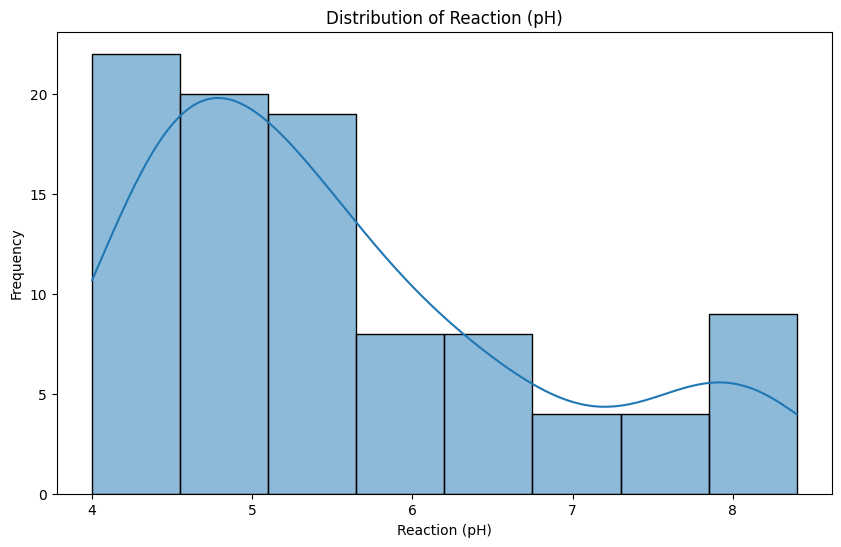

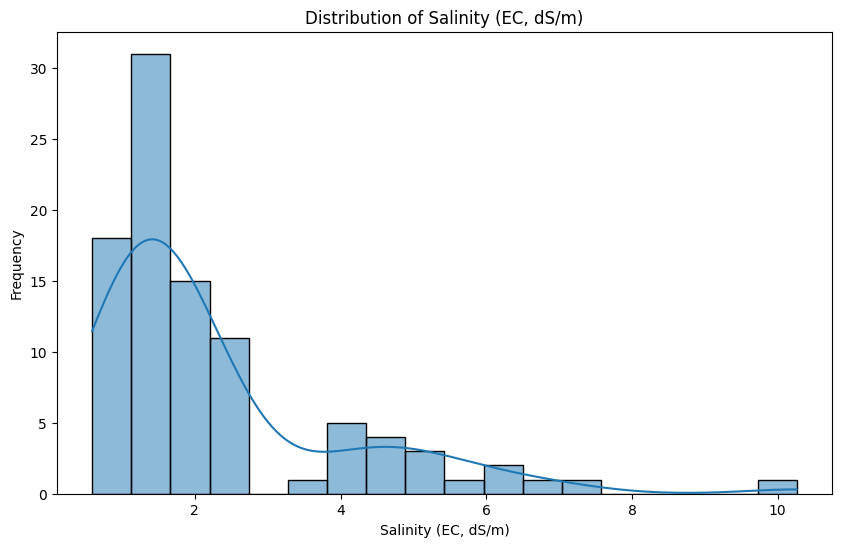

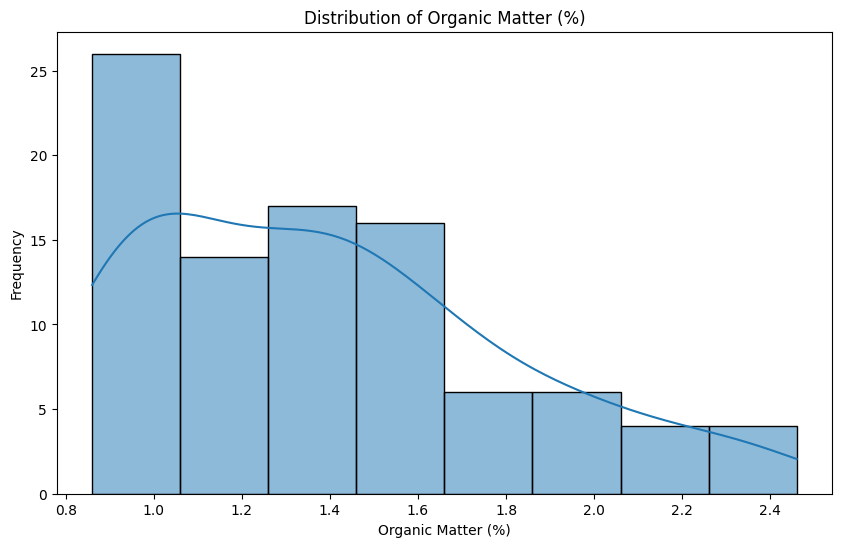

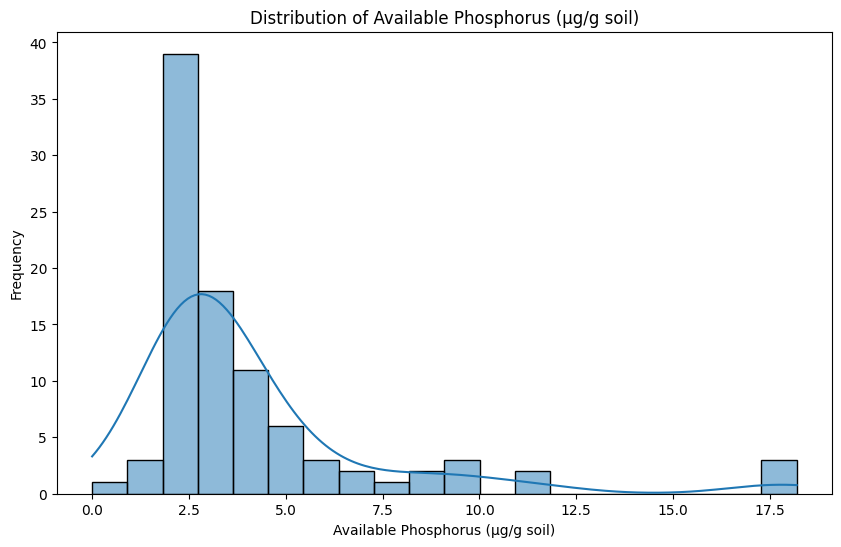

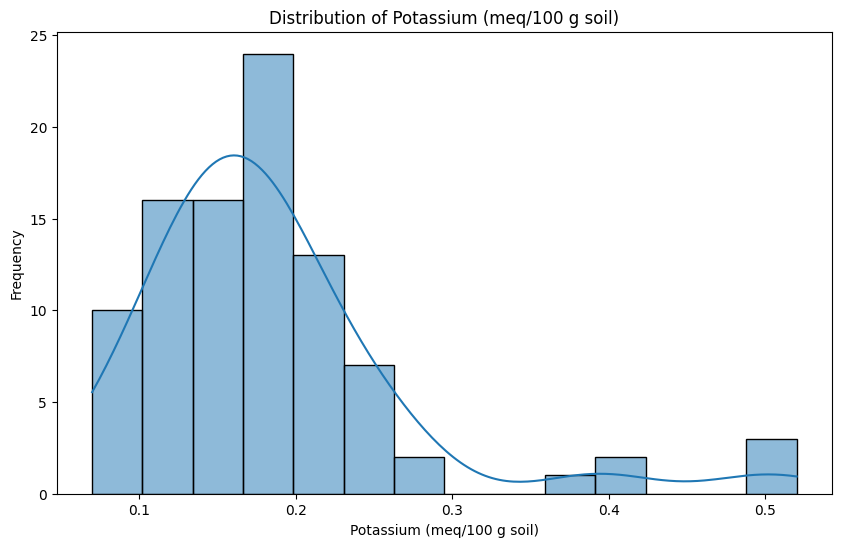

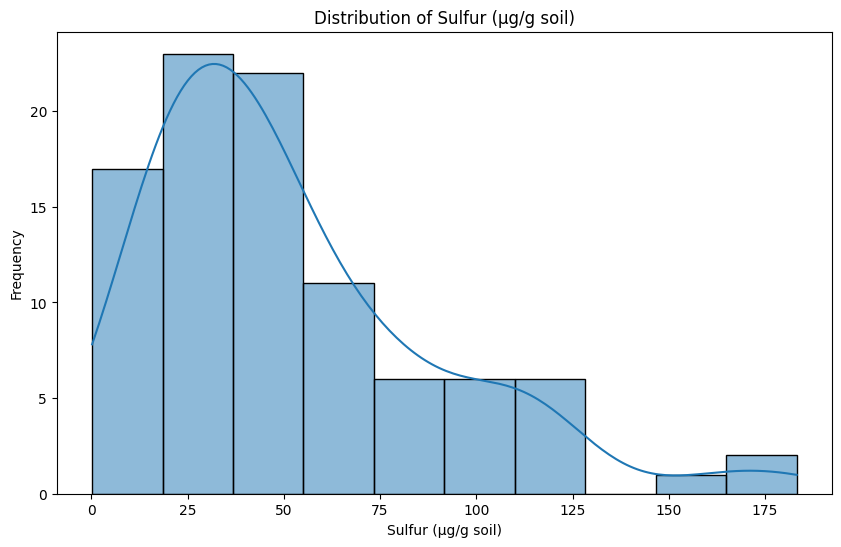

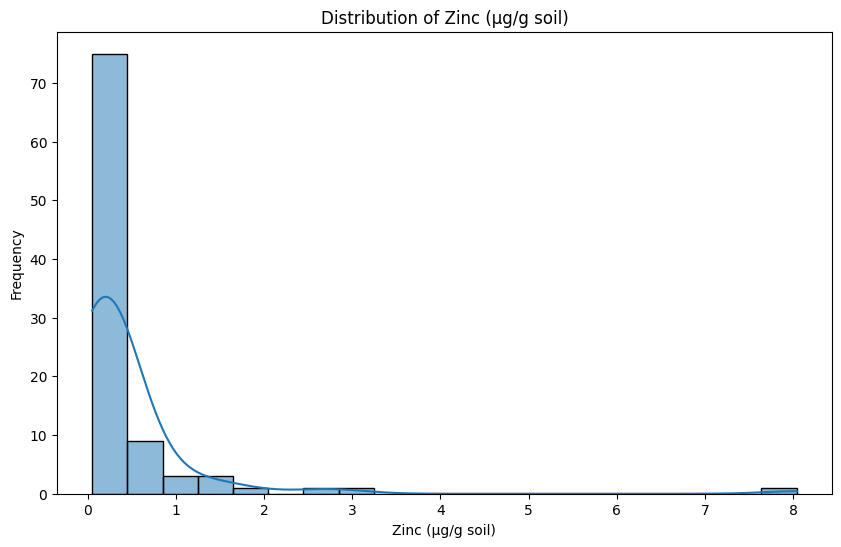

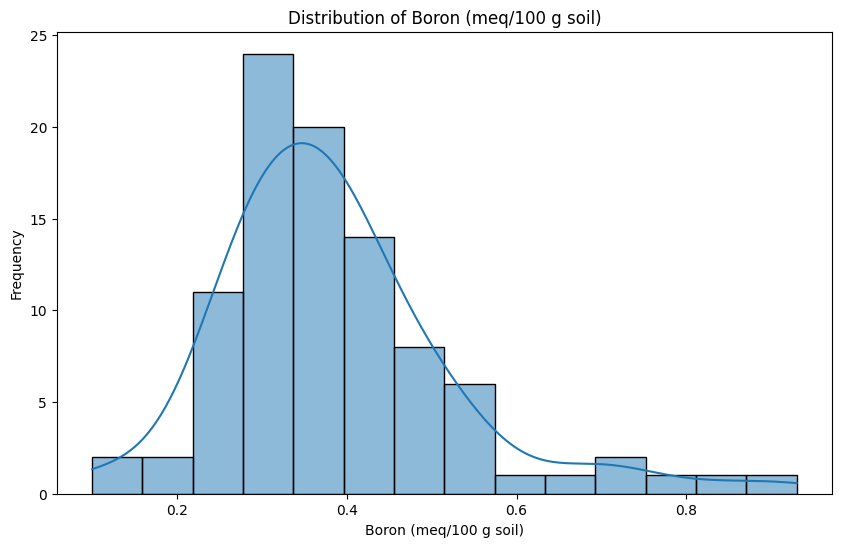

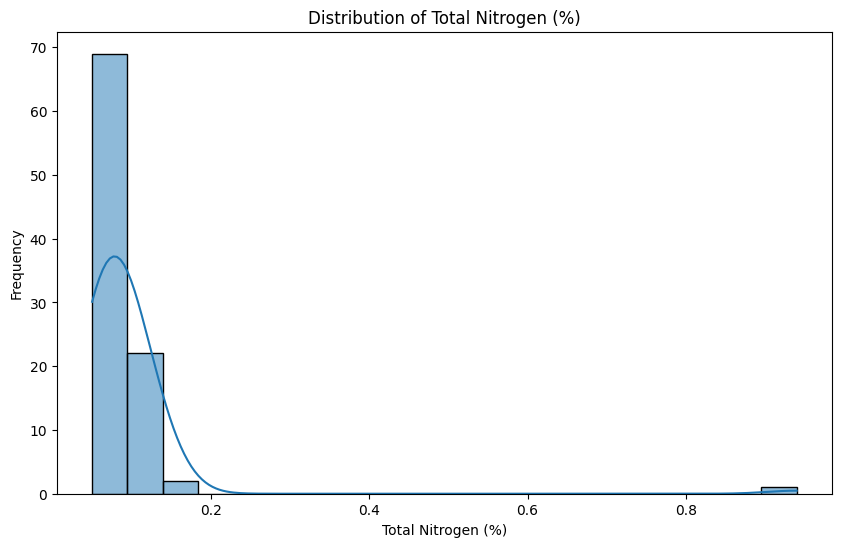

In [157]:
for col in numeric_columns + [TARGET]:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Axes: >

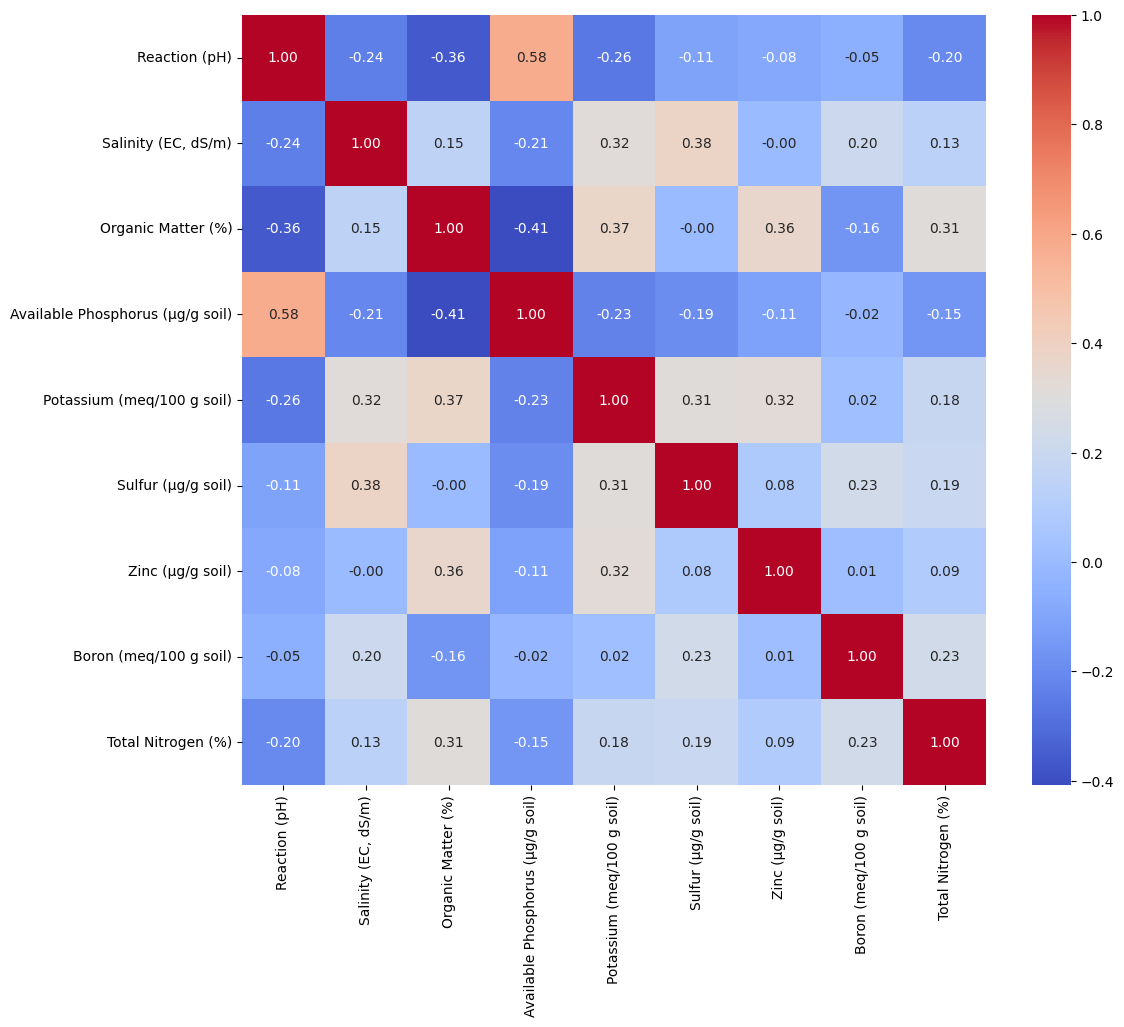

In [158]:
corr_cols = numeric_columns + [TARGET]
corr_df = df[corr_cols].copy()
plt.figure(figsize=(12,10))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [159]:
df[numeric_columns + [TARGET]].describe()

,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Available Phosphorus (µg/g soil),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Total Nitrogen (%)
count,94.000000,94.000000,93.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.00000
mean,5.543617,2.254362,1.392581,4.137766,0.184362,51.976277,0.430000,0.385745,0.09067
std,1.225321,1.752230,0.415880,3.316060,0.085792,37.614258,0.927097,0.140157,0.09179
min,4.000000,0.590000,0.860000,0.000000,0.070000,0.230000,0.050000,0.100000,0.05000
25%,4.600000,1.190000,1.020000,2.380000,0.130000,25.737500,0.100000,0.300000,0.06000
50%,5.250000,1.610000,1.350000,2.930000,0.170000,43.040000,0.190000,0.365000,0.08000
75%,6.200000,2.422500,1.630000,4.152500,0.207500,70.175000,0.365000,0.437500,0.10000
max,8.400000,10.260000,2.460000,18.190000,0.520000,183.200000,8.040000,0.930000,0.94000


In [160]:
df[df["Zinc (µg/g soil)"] > 5]

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
16,79,Jhalokathi,Medium high land,Clay loam,5.3,1.95,2.41,0.14,0.38,31.34,8.04,0.4,6.7,7.33,3.5,41.28,2.51


In [161]:
# df = df[df[TARGET]> 0.1]

In [162]:
filtered_df = df[
    (df["District"] == "Jhalokathi") &
    (df["Land Class"] == "Medium high land") &
    (df["Soil Texture"] == "Clay loam") &
    (df["Reaction (pH)"] > 5) &
    (df["Reaction (pH)"] < 6) &
    (df["Salinity (EC, dS/m)"] == 1.95)
]

filtered_df

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
15,78,Jhalokathi,Medium high land,Clay loam,5.4,1.95,2.29,0.13,0.20,43.19,0.28,0.28,5.93,3.74,3.57,14.55,4.05
16,79,Jhalokathi,Medium high land,Clay loam,5.3,1.95,2.41,0.14,0.38,31.34,8.04,0.40,6.70,7.33,3.50,41.28,2.51


In [163]:
df.loc[df["Zinc (µg/g soil)"] == 8.04, "Zinc (µg/g soil)"] = 0.84

In [164]:
# df[df["Manganese (µg/g soil)"] > 10]

In [165]:
df[df["Sulfur (µg/g soil)"] > 75]

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
2,27,Rangamati,Medium high land,Loam,6.8,5.59,1.34,0.08,0.07,94.54,0.16,0.32,6.58,2.28,0.89,1.12,4.78
17,86,Jhalokathi,Medium high land,Clay loam,5.1,4.82,NaN,0.13,0.40,183.20,0.98,0.45,9.20,3.90,4.22,45.74,4.82
20,18,Rangamati,Medium high land,Loam,5.0,1.24,2.24,0.13,0.23,75.50,2.56,0.41,7.05,3.12,4.23,30.49,2.36
26,59,Rangamati,Medium high land,Loam,4.5,1.86,1.80,0.10,0.17,81.22,0.39,0.21,3.50,2.55,2.64,5.68,2.49
31,2,Jhalokathi,Medium high land,Clay loam,4.5,4.06,1.14,0.07,0.21,109.04,0.17,0.36,3.26,2.62,2.21,6.75,2.31
36,17,Jhalokathi,Medium high land,Clay loam,4.8,0.98,1.50,0.09,0.22,81.21,0.24,0.61,4.65,2.64,3.72,13.07,2.17
42,25,Jhalokathi,Medium high land,Clay loam,4.5,2.51,1.35,0.08,0.21,80.19,0.12,0.52,2.94,2.86,2.11,8.24,3.84
49,49,Jhalokathi,Medium high land,Clay loam,4.4,6.02,1.42,0.08,0.20,94.51,0.33,0.38,4.04,3.79,3.76,8.17,1.92
50,51,Jhalokathi,Medium high land,Clay loam,4.2,7.21,1.62,0.09,0.20,108.50,0.48,0.28,3.06,3.17,3.52,10.97,2.67
51,58,Jhalokathi,Medium high land,Clay loam,4.3,1.36,1.46,0.09,0.19,113.00,0.48,0.30,4.45,3.08,3.22,7.19,1.84


In [166]:
# df[
#     (df["District"] == "Jhalokathi") &
#     (df["Land Class"] == "Medium high land") &
#     (df["Soil Texture"] == "Clay loam") &
#     (df["Reaction (pH)"] > 4) &
#     (df["Reaction (pH)"] < 5)
# ]

In [167]:
df.loc[df[TARGET] == 0.94, TARGET] = 0.094

In [168]:
# df = df[df[TARGET]> 0.4]
# df


In [169]:
df.describe()

,Soil Sample Serial No.,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
count,94.000000,94.000000,94.000000,93.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,46.808511,5.543617,2.254362,1.392581,0.081670,0.184362,51.976277,0.353404,0.385745,5.354255,2.810532,2.529149,7.772234,4.137766
std,26.884171,1.225321,1.752230,0.415880,0.024231,0.085792,37.614258,0.482365,0.140157,4.201484,0.945580,0.948367,9.429750,3.316060
min,1.000000,4.000000,0.590000,0.860000,0.050000,0.070000,0.230000,0.050000,0.100000,1.120000,1.150000,0.700000,0.640000,0.000000
25%,24.250000,4.600000,1.190000,1.020000,0.060000,0.130000,25.737500,0.100000,0.300000,2.415000,2.192500,1.805000,2.620000,2.380000
50%,46.500000,5.250000,1.610000,1.350000,0.080000,0.170000,43.040000,0.190000,0.365000,4.275000,2.645000,2.300000,5.080000,2.930000
75%,69.750000,6.200000,2.422500,1.630000,0.098500,0.207500,70.175000,0.365000,0.437500,6.535000,3.335000,3.465000,7.777500,4.152500
max,93.000000,8.400000,10.260000,2.460000,0.140000,0.520000,183.200000,2.880000,0.930000,20.510000,7.330000,4.600000,45.740000,18.190000


In [170]:
df[df["Available Phosphorus (µg/g soil)"] > 5]

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
0,4,Ramgati,Medium high land,Loam,8.0,1.63,0.95,0.06,0.07,20.30,0.09,0.35,7.06,1.83,0.70,1.08,18.19
38,21,Jhalokathi,Medium high land,Clay loam,4.6,4.59,1.00,0.06,0.14,21.09,0.09,0.49,2.34,2.50,1.57,4.07,6.94
65,46,Jhalokathi,Medium high land,Clay loam,5.0,0.59,1.11,0.06,0.14,32.76,0.88,0.50,1.27,2.00,4.52,7.78,7.19
68,65,Jhalokathi,Medium high land,Loam,4.5,1.40,1.63,0.10,0.17,27.89,0.14,0.33,3.79,3.28,2.28,2.58,5.95
69,68,Jhalokathi,Medium high land,Clay loam,4.7,1.70,1.40,0.08,0.17,6.95,0.37,0.42,1.85,2.19,2.60,2.79,5.84
72,13,Barishal,Medium high land,Clay loam,4.2,2.23,1.22,0.07,0.17,113.60,0.77,0.33,1.86,2.78,3.72,5.82,5.47
76,70,Bhola,Medium high land,Clay loam,6.8,1.68,1.20,0.07,0.09,48.80,0.09,0.37,2.17,2.31,1.76,7.61,9.04
77,55,Nilkamal,Medium high land,Clay loam,7.6,1.71,0.91,0.05,0.16,48.67,0.06,0.36,7.24,1.93,1.52,3.20,5.19
85,32,Meghnar Paschimati,Medium high land,Loam,5.6,0.69,0.95,0.06,0.13,12.62,0.09,0.46,15.45,1.58,4.04,6.01,11.51
86,32,Meghnar Paschimati,Medium low land,Loam,8.2,0.69,0.95,0.06,0.13,12.62,0.09,0.46,15.45,1.58,4.04,6.01,11.51


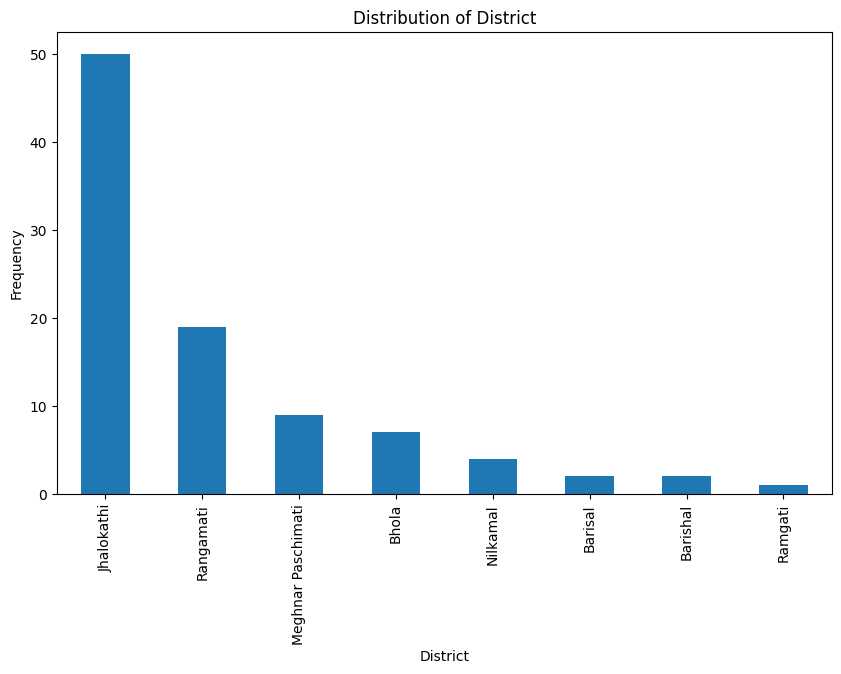

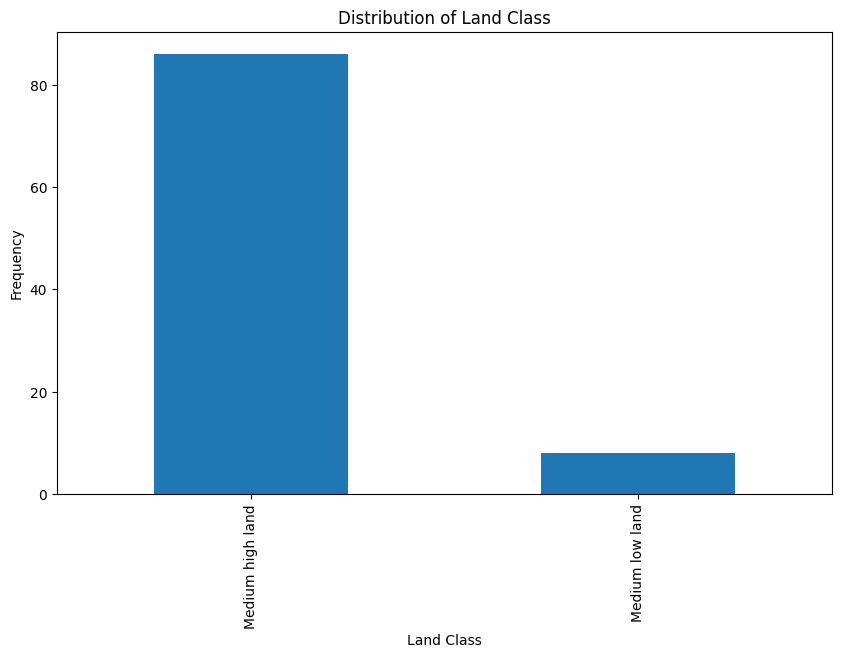

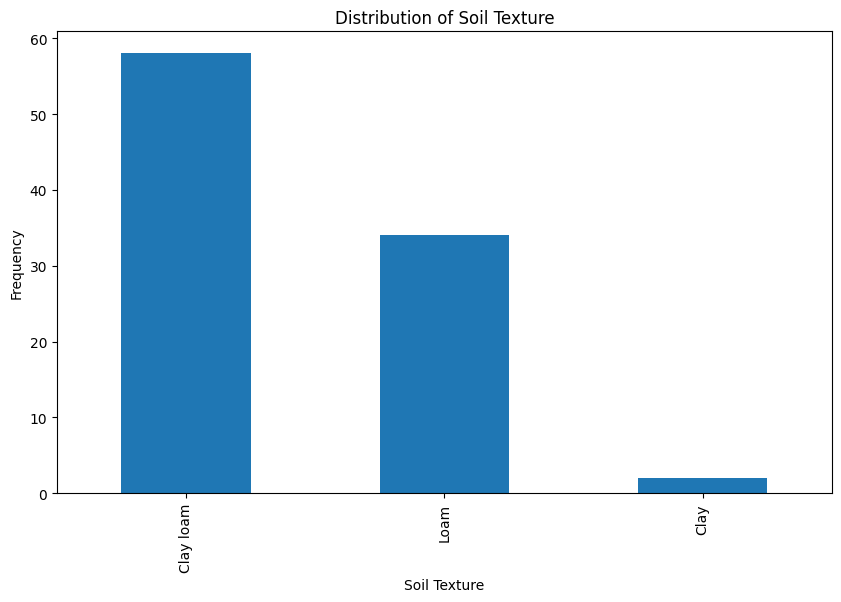

In [171]:
for cols in categorical_columns:
    plt.figure(figsize=(10,6))
    
    df[cols].value_counts().plot(kind='bar')
    
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

In [172]:
df["District"] = df["District"].replace({"Ramgati": "Rangamati", "Barisal": "Barishal"})

In [173]:
df["District"].value_counts()

District
Jhalokathi            50
Rangamati             20
Meghnar Paschimati     9
Bhola                  7
Barishal               4
Nilkamal               4
Name: count, dtype: int64

Analyze the relationship between Nitrogen and categorical columns(District, Land Class, Soil Texture)

Category-wise N Distribution

In [174]:
for col in categorical_columns:
    print(f"\nRelationship between {col} and {TARGET}")
    print(df.groupby(col)[TARGET].agg(["mean", "median", "std"]))


Relationship between District and Total Nitrogen (%)
                        mean  median       std
District                                      
Barishal            0.067500    0.07  0.012583
Bhola               0.064286    0.06  0.012724
Jhalokathi          0.084340    0.08  0.022003
Meghnar Paschimati  0.053333    0.05  0.005000
Nilkamal            0.072500    0.07  0.022174
Rangamati           0.098500    0.10  0.024339

Relationship between Land Class and Total Nitrogen (%)
                      mean  median       std
Land Class                                  
Medium high land  0.084384    0.08  0.023518
Medium low land   0.052500    0.05  0.004629

Relationship between Soil Texture and Total Nitrogen (%)
                  mean  median       std
Soil Texture                            
Clay          0.075000   0.075  0.007071
Clay loam     0.081672   0.080  0.021886
Loam          0.082059   0.080  0.028686


Interpretation of ANOVA

ANOVA means Analysis of Variance.

It is a statistical test used to check whether the average value of a numerical column is significantly different across multiple categories/groups.

Example:

Does average Total Nitrogen (%) differ across Districts?

ANOVA tells:

p-value < 0.05  → group averages are significantly different
p-value >= 0.05 → no strong evidence of difference

In simple words: ANOVA checks whether categories have meaningfully different average values.

In [175]:
from scipy.stats import f_oneway

for col in categorical_columns:
    print(f"\nANOVA for {col} and {TARGET}")
    groups = [group[TARGET] for name, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)

    print("F-statistic:", f_stat)
    print("p-value:", p_value)


ANOVA for District and Total Nitrogen (%)
F-statistic: 7.623562529282214
p-value: 5.449222873509193e-06

ANOVA for Land Class and Total Nitrogen (%)
F-statistic: 14.514132760529975
p-value: 0.0002509749666537327

ANOVA for Soil Texture and Total Nitrogen (%)
F-statistic: 0.07856341476118499
p-value: 0.924506066500044


A one-way ANOVA was performed to examine whether Total Nitrogen (%) differs across different categorical soil features: District, Land Class, and Soil Texture.

For District, the ANOVA result was statistically significant, F = 7.62, p = 0.00000545. Since the p-value is much smaller than 0.05, this indicates that Total Nitrogen (%) differs significantly among districts. Therefore, District has a meaningful relationship with Total Nitrogen (%) in this dataset.

For Land Class, the ANOVA result was also statistically significant, F = 14.51, p = 0.000251. Since the p-value is smaller than 0.05, this means Total Nitrogen (%) differs significantly across different land classes. Among the tested categorical variables, Land Class shows the strongest relationship with Total Nitrogen (%) because it has the highest F-statistic.

For Soil Texture, the ANOVA result was not statistically significant, F = 0.079, p = 0.925. Since the p-value is much greater than 0.05, there is no strong evidence that Total Nitrogen (%) differs across soil texture categories in this dataset.

Overall, the results suggest that District and Land Class are significantly associated with Total Nitrogen (%), while Soil Texture does not show a statistically meaningful relationship with Total Nitrogen (%). However, ANOVA only tells us that differences exist; it does not tell exactly which districts or land classes differ from each other. For that, a post-hoc test such as Tukey HSD should be used.

Boxplot Observation

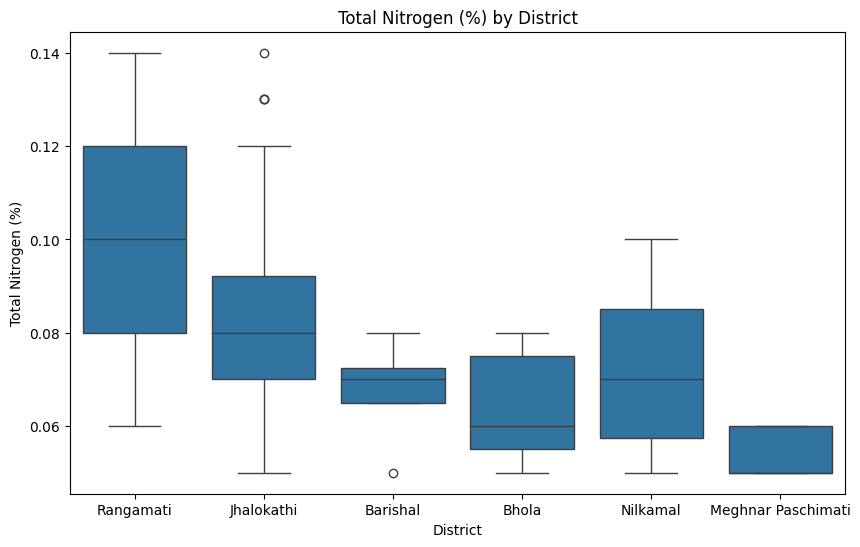

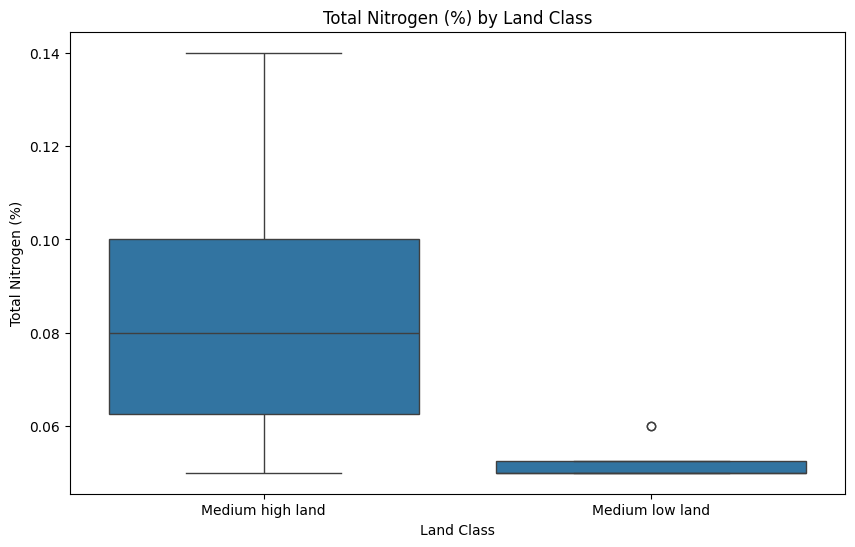

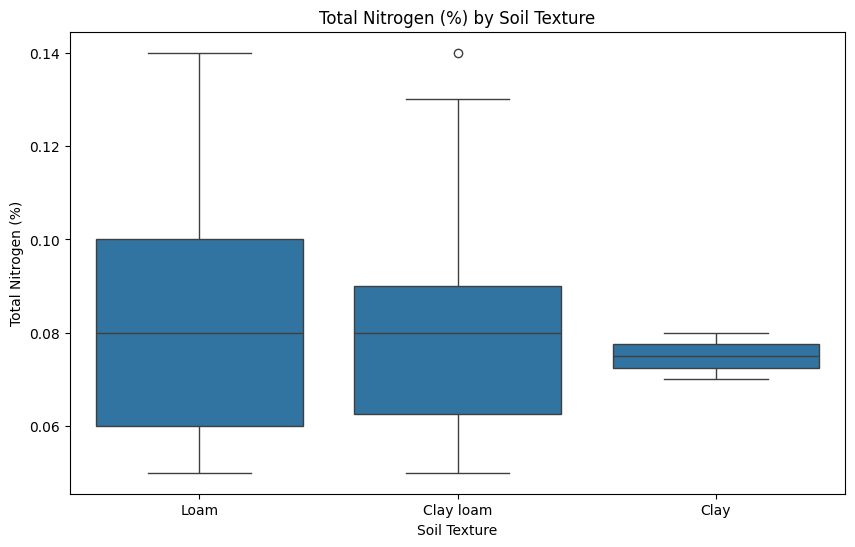

In [176]:
for col in categorical_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=col, y=TARGET, data=df)
    plt.title(f"{TARGET} by {col}")
    plt.show()

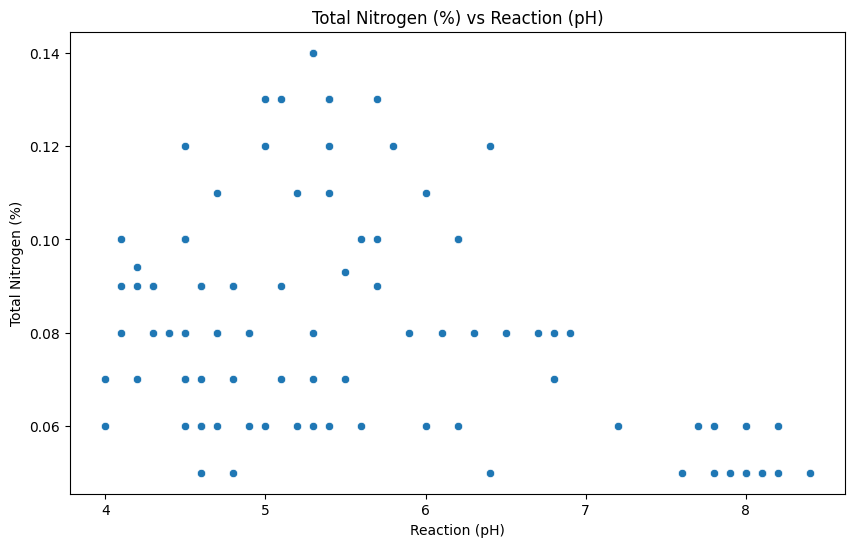

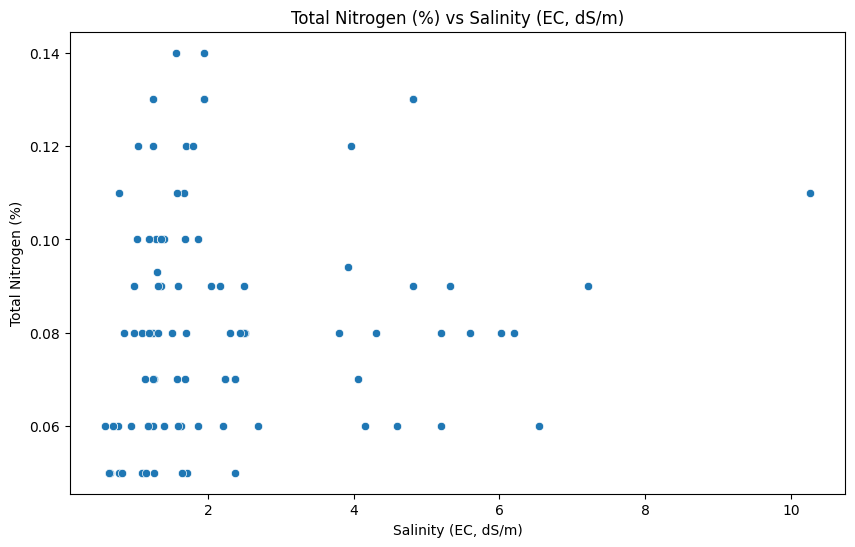

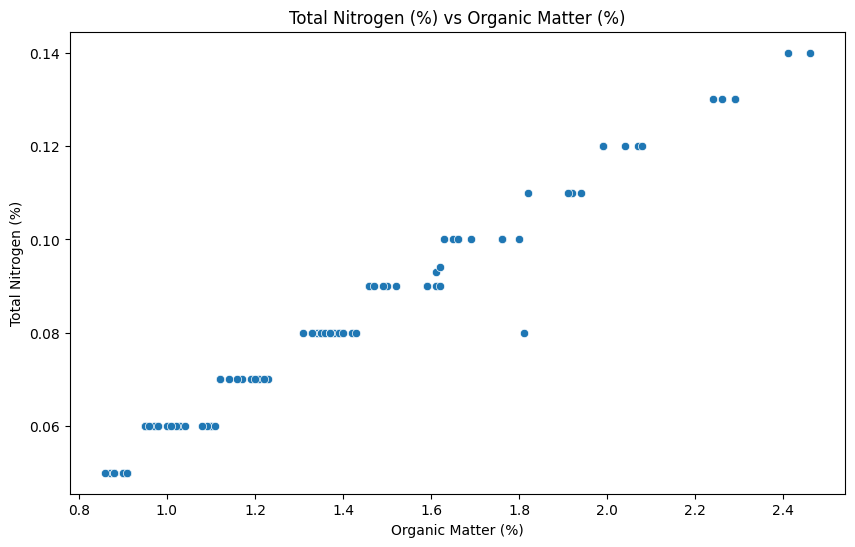

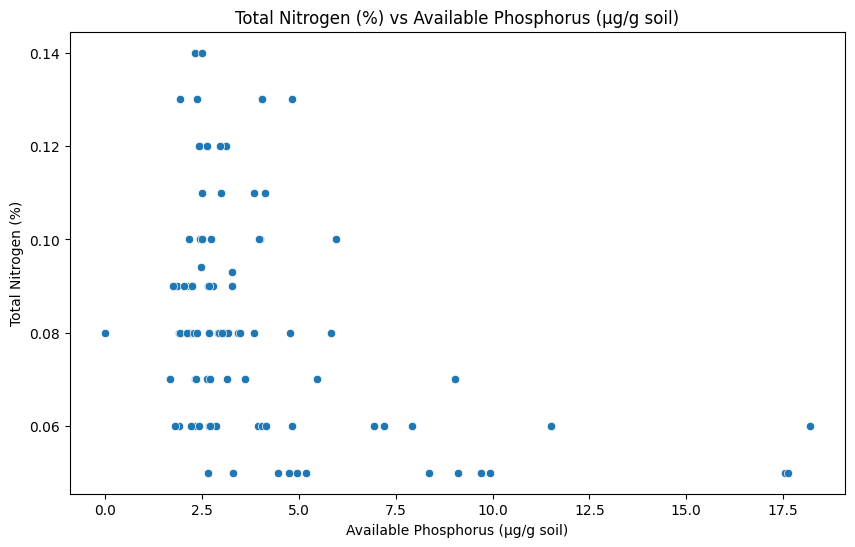

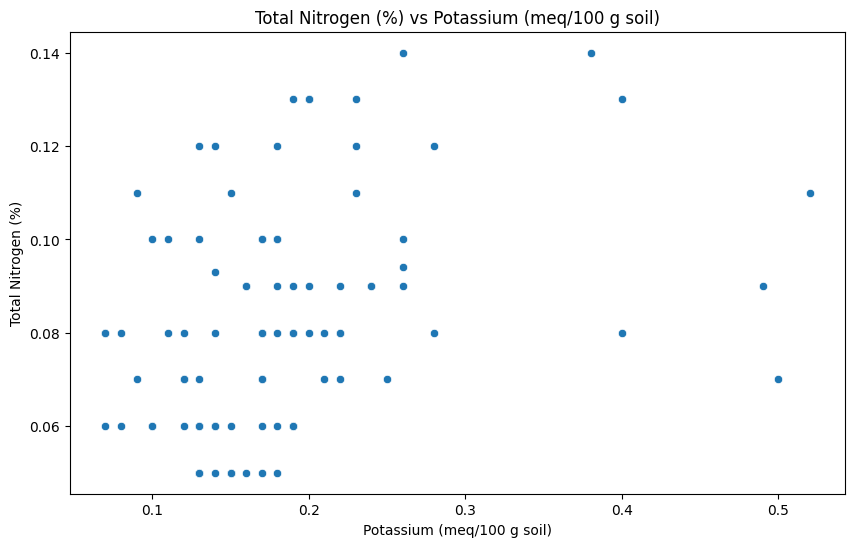

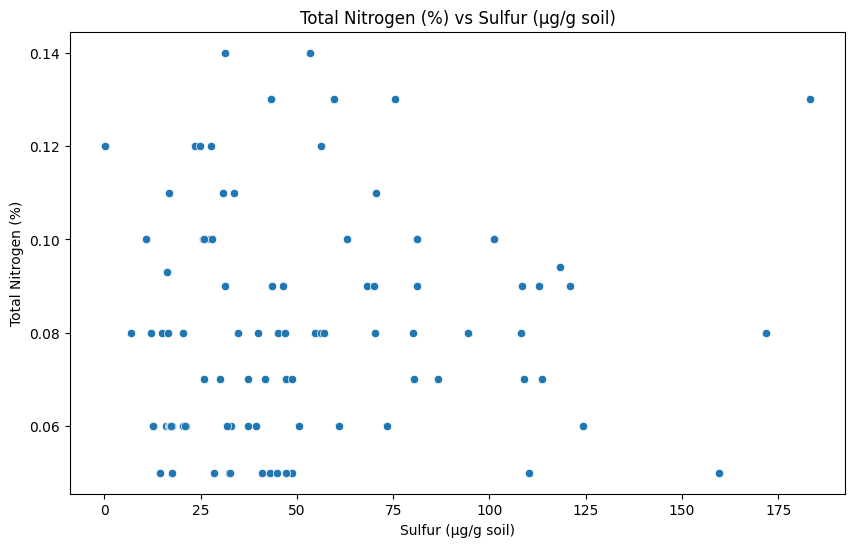

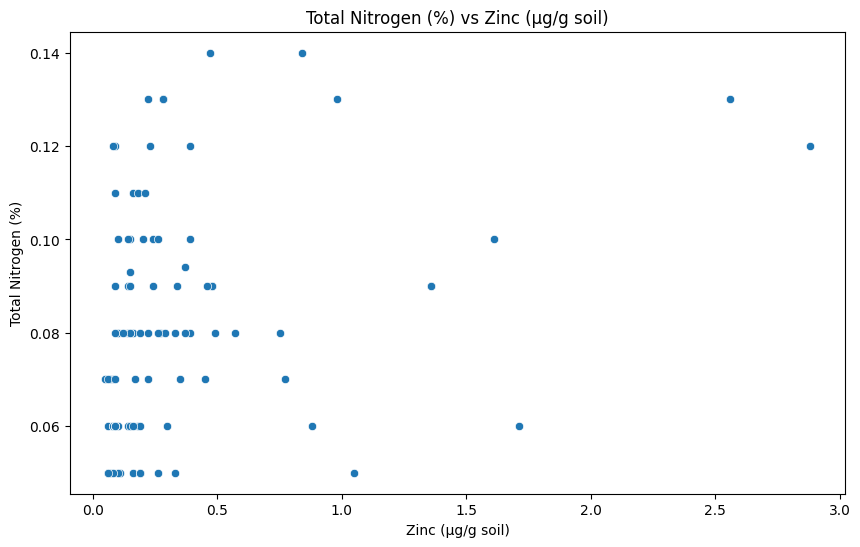

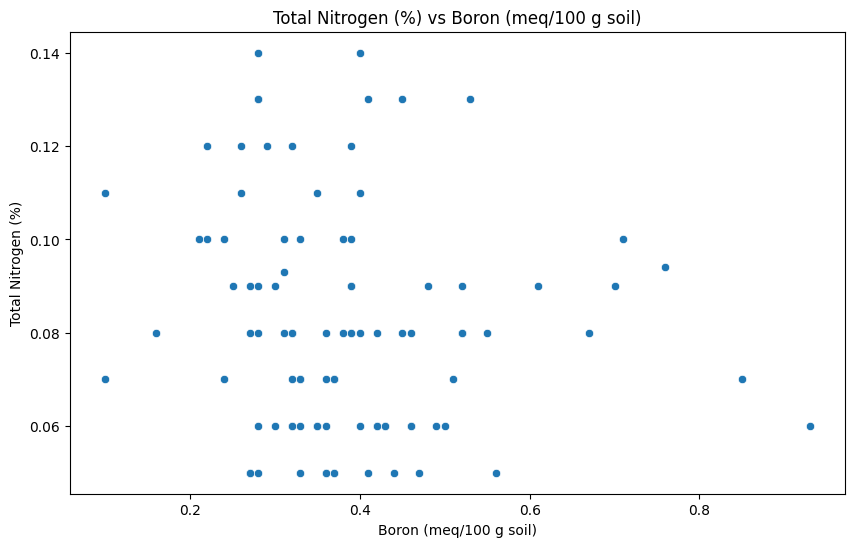

In [177]:
for col in numeric_columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=col, y=TARGET, data=df)
    plt.title(f"{TARGET} vs {col}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.show()

In [178]:
from scipy.stats import pearsonr
for col in numeric_columns:
    corr, p_value = pearsonr(df[col], df[TARGET])
    
    print(f"\n{col}")
    print("Pearson correlation:", corr)
    print("p-value:", p_value)


Reaction (pH)
Pearson correlation: -0.35783221328271675
p-value: 0.0003987693907159738

Salinity (EC, dS/m)
Pearson correlation: 0.15204111230134715
p-value: 0.143497641475596

Organic Matter (%)
Pearson correlation: nan
p-value: nan

Available Phosphorus (µg/g soil)
Pearson correlation: -0.3988080164486273
p-value: 6.852444929921961e-05

Potassium (meq/100 g soil)
Pearson correlation: 0.3606033482353003
p-value: 0.0003565548734347713

Sulfur (µg/g soil)
Pearson correlation: 0.07276612838871085
p-value: 0.48581588684526356

Zinc (µg/g soil)
Pearson correlation: 0.30446085427245717
p-value: 0.0028493969801283684

Boron (meq/100 g soil)
Pearson correlation: -0.1294711332908015
p-value: 0.21360407926352273


corr near +1  = strong positive linear relation
corr near -1  = strong negative linear relation
corr near 0   = weak/no linear relation

In [179]:
feature_columns = numeric_columns + categorical_columns

X = df[feature_columns].copy()
y = df[TARGET].copy()

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (94, 11)
Target (y) shape: (94,)


In [180]:
print(X.columns)

Index(['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)',
       'Available Phosphorus (µg/g soil)', 'Potassium (meq/100 g soil)',
       'Sulfur (µg/g soil)', 'Zinc (µg/g soil)', 'Boron (meq/100 g soil)',
       'District', 'Land Class', 'Soil Texture'],
      dtype='object')


Train Test Split

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Training target shape:", y_train.shape) 
print("Testing features shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (75, 11)
Training target shape: (75,)
Testing features shape: (19, 11)
Testing target shape: (19,)


Create Preprocessing Pipeline

In [ ]:
# numeric_transformer = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy='median')),
#         ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy='most_frequent')),
#     ("onehot", OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_columns),
#         ("cat", categorical_transformer, categorical_columns)
#     ]
# )

In [183]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [184]:
MLFLOW_TRACKING_URI = "file:./mlruns"
EXPERIMENT_NAME = "nitrogen_prediction_experiment_v2"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

2026/05/19 15:48:05 INFO mlflow.tracking.fluent: Experiment with name 'nitrogen_prediction_experiment_v2' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/project/n-prediction-mlflow/mlruns/323396794287081459', creation_time=1779184085145, experiment_id='323396794287081459', last_update_time=1779184085145, lifecycle_stage='active', name='nitrogen_prediction_experiment_v2', tags={}, trace_location=None, workspace='default'>

In [185]:
models_and_params = {"RandomForest": {
    "model": RandomForestRegressor(),
    "params": {
        "regressor__n_estimators": [100, 200, 300],
        "regressor__max_depth": [None, 10, 20]
    }
}}

In [186]:
MIN_NUM_FEATURES = 3
MAX_NUM_FEATURES = len(numeric_columns)

print(f"Minimum number of features: {MIN_NUM_FEATURES}")
print(f"Maximum number of features: {MAX_NUM_FEATURES}")

Minimum number of features: 3
Maximum number of features: 8


In [187]:
def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(MIN_NUM_FEATURES, MAX_NUM_FEATURES + 1))

In [189]:
results = []

for num_feature_combination in powerset(numeric_columns):
    
    selected_numeric_columns = list(num_feature_combination)
    combo_name = "_".join([col.split()[0] for col in selected_numeric_columns])
    
    print(f"\n{'='*70}")
    print(f"Feature Combination: {selected_numeric_columns} ({len(selected_numeric_columns)} numeric features)")
    print(f"Combo Name: {combo_name}")
    print(f"{'='*70}")
    
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
    transformers=[
            ("num", numeric_transformer, selected_numeric_columns),
            ("cat", categorical_transformer, categorical_columns)
        ]
    )
    
    for model_name, config in models_and_params.items():
        model = config["model"]
        param_grid = list(ParameterGrid(config["params"]))
        
        print(f"→ Training {model_name} | Total hyperparameter runs: {len(param_grid)}")
        
        for run_number, params in enumerate(param_grid, start=1):
            with mlflow.start_run(run_name=f"{model_name}_{combo_name}_run_{run_number}"):
                pipeline = Pipeline(steps=[
                    ("preprocessor", preprocessor),
                    ("regressor", model)
                ])
                pipeline.set_params(**params)
                pipeline.fit(X_train, y_train)
                y_train_pred = pipeline.predict(X_train)
                y_test_pred = pipeline.predict(X_test)
                
                train_metrics = evaluate_model(y_train, y_train_pred)
                test_metrics = evaluate_model(y_test, y_test_pred)
                
                mlflow.log_param("model_name", model_name)
                mlflow.log_param("feature_combo", combo_name)
                mlflow.log_param("selected_numeric_features", selected_numeric_columns)
                mlflow.log_param("num_numeric_features", len(selected_numeric_columns))
                mlflow.log_param("total_features", len(selected_numeric_columns) + len(categorical_columns))
                mlflow.log_param("target", TARGET)
                
                for param_name, param_value in params.items():
                    clean_param_name = param_name.replace("regressor__", "")
                    mlflow.log_param(clean_param_name, param_value)
                
                mlflow.log_metric("train_MAE", train_metrics["MAE"])
                mlflow.log_metric("train_MSE", train_metrics["MSE"])
                mlflow.log_metric("train_RMSE", train_metrics["RMSE"])
                mlflow.log_metric("train_R2", train_metrics["R2 Score"])

                mlflow.log_metric("test_MAE", test_metrics["MAE"])
                mlflow.log_metric("test_MSE", test_metrics["MSE"])
                mlflow.log_metric("test_RMSE", test_metrics["RMSE"])
                mlflow.log_metric("test_R2", test_metrics["R2 Score"])
                
                mlflow.sklearn.log_model(pipeline, artifact_path="model")
                
                result_row = {
                    "model_name": model_name,
                    "combo_name": combo_name,
                    "num_features": len(selected_numeric_columns),
                    "features_used": selected_numeric_columns,
                    "params": params,
                    "train_metrics": train_metrics,
                    "test_metrics": test_metrics
                }
                
                results.append(result_row)
                
                print(
                    f"{model_name} run {run_number} | "
                    f"Test RMSE: {test_metrics['RMSE']:.4f} | "
                    f"Test R2: {test_metrics['R2 Score']:.4f}"
                )

2026/05/19 15:56:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Feature Combination: ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)'] (3 numeric features)
Combo Name: Reaction_Salinity_Organic
→ Training RandomForest | Total hyperparameter runs: 9


2026/05/19 15:56:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 1 | Test RMSE: 0.0076 | Test R2: 0.8622


2026/05/19 15:56:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 15:56:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RandomForest run 7 | Test RMSE: 0.0040 | Test R2: 0.9615


2026/05/19 18:03:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 18:03:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 8 | Test RMSE: 0.0030 | Test R2: 0.9783


2026/05/19 18:03:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 18:03:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 9 | Test RMSE: 0.0031 | Test R2: 0.9773
